In [1]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt
# Check PyTorch version
torch.__version__

'2.9.0+cu126'

# 1. Create a straight line dataset using the linear regression formula (weight * X + bias).

In [2]:
# Create *known* parameters
weight = 0.3
bias = 0.9

# Create data
start = 0
end = 2
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.9000],
         [0.9060],
         [0.9120],
         [0.9180],
         [0.9240],
         [0.9300],
         [0.9360],
         [0.9420],
         [0.9480],
         [0.9540]]))

In [3]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [4]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

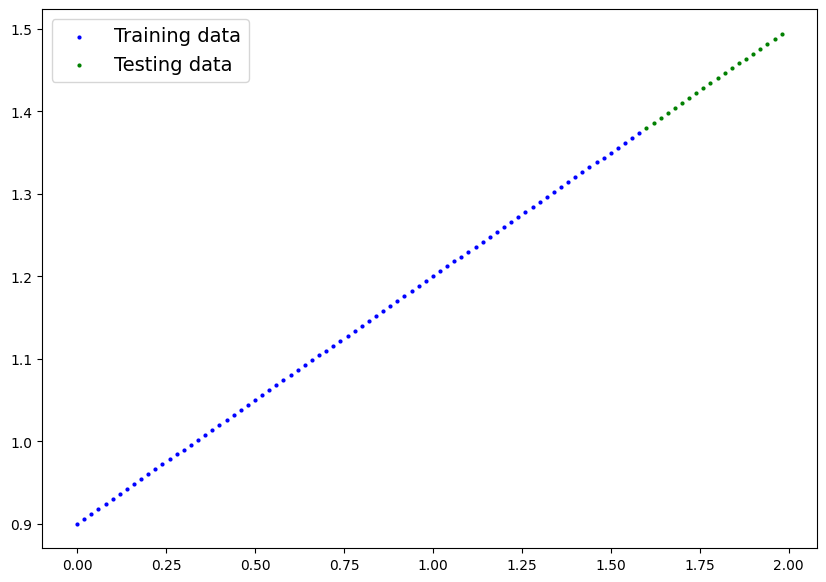

In [5]:
plot_predictions();

# 2. Build a PyTorch model by subclassing nn.Module

In [6]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                dtype=torch.float),
                                   requires_grad=True)

        self.bias = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                requires_grad=True)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [7]:
# Set manual seed since nn.Parameter are randomly initialzied
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# 3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.

In [9]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [10]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 300

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing
    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())

      # Each 20 epochs
      if epoch % 20 == 0:
        print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.7422052025794983 | MAE Test Loss: 0.6813738942146301 
Epoch: 20 | MAE Train Loss: 0.41738519072532654 | MAE Test Loss: 0.1985538750886917 
Epoch: 40 | MAE Train Loss: 0.16582420468330383 | MAE Test Loss: 0.19161489605903625 
Epoch: 60 | MAE Train Loss: 0.13492025434970856 | MAE Test Loss: 0.2436906397342682 
Epoch: 80 | MAE Train Loss: 0.11619293689727783 | MAE Test Loss: 0.2253524363040924 
Epoch: 100 | MAE Train Loss: 0.09796369075775146 | MAE Test Loss: 0.19259914755821228 
Epoch: 120 | MAE Train Loss: 0.07977813482284546 | MAE Test Loss: 0.156447634100914 
Epoch: 140 | MAE Train Loss: 0.061592668294906616 | MAE Test Loss: 0.12029661238193512 
Epoch: 160 | MAE Train Loss: 0.04340718686580658 | MAE Test Loss: 0.08482521772384644 
Epoch: 180 | MAE Train Loss: 0.025222454220056534 | MAE Test Loss: 0.04867418482899666 
Epoch: 200 | MAE Train Loss: 0.007037716452032328 | MAE Test Loss: 0.012523150071501732 
Epoch: 220 | MAE Train Loss: 0.010932961478829384 | 

In [12]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[1.3967],
        [1.4028],
        [1.4090],
        [1.4151],
        [1.4213],
        [1.4274],
        [1.4336],
        [1.4397],
        [1.4458],
        [1.4520],
        [1.4581],
        [1.4643],
        [1.4704],
        [1.4766],
        [1.4827],
        [1.4888],
        [1.4950],
        [1.5011],
        [1.5073],
        [1.5134]])

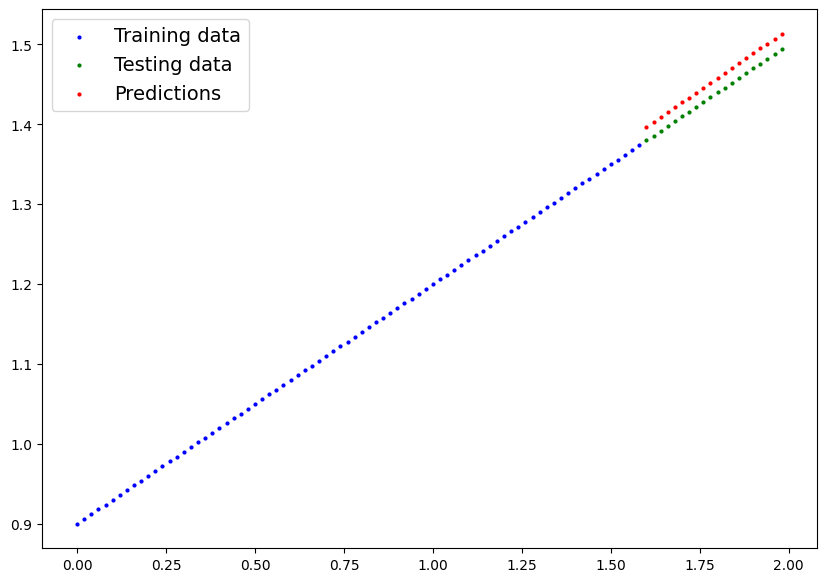

In [13]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())

In [19]:
torch.save(model_0.state_dict(), 'state_dict.py')

In [20]:
model_1 = LinearRegressionModel()

model_1.load_state_dict(torch.load('state_dict.py'))

<All keys matched successfully>

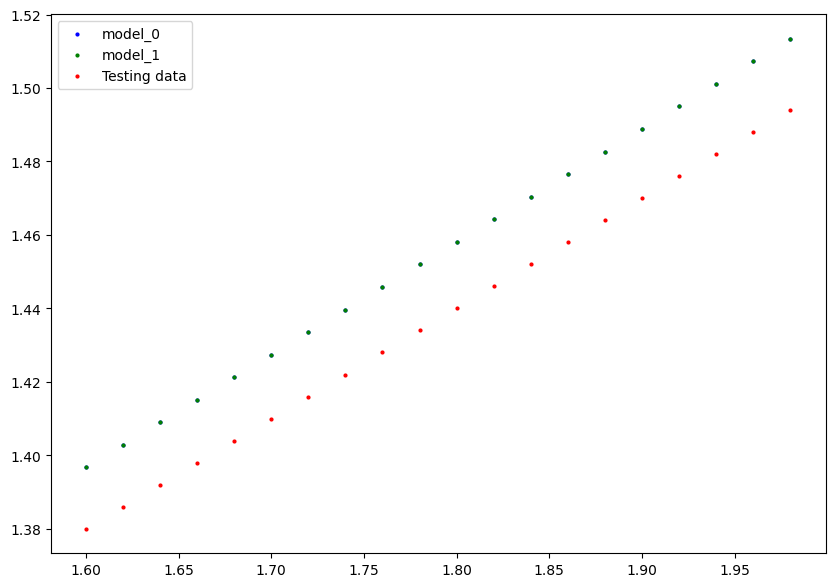

In [24]:
model_1.eval()

with torch.inference_mode():
  y_preds_1 = model_1(X_test)

plt.figure(figsize=(10, 7))

# Plot model_0 in blue
plt.scatter(X_test, y_preds, c="b", s=4, label="model_0")

# Plot model_1 in green
plt.scatter(X_test, y_preds_1, c="g", s=4, label="model_1")

# Plot test data in green
plt.scatter(X_test, y_test, c="r", s=4, label="Testing data")


plt.legend()